# EDA

In [2]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Pull in the datasets
survey_clean = pd.read_csv('Data/survey_df_clean.csv')
hai_clean = pd.read_csv('Data/ha_df_clean.csv')
timely_clean = pd.read_csv('Data/timely_df_clean.csv')

# Double check datasets pulled in successfully
print(survey_clean.head(5))
print(hai_clean.head(5))
print(timely_clean.head(5))

  Facility ID                    Facility Name     HCAHPS Measure ID  \
0      010001  SOUTHEAST HEALTH MEDICAL CENTER  H_COMP_1_STAR_RATING   
1      010001  SOUTHEAST HEALTH MEDICAL CENTER  H_COMP_2_STAR_RATING   
2      010001  SOUTHEAST HEALTH MEDICAL CENTER  H_COMP_5_STAR_RATING   
3      010001  SOUTHEAST HEALTH MEDICAL CENTER  H_COMP_6_STAR_RATING   
4      010001  SOUTHEAST HEALTH MEDICAL CENTER   H_CLEAN_STAR_RATING   

                               HCAHPS Question  \
0            Nurse communication - star rating   
1           Doctor communication - star rating   
2  Communication about medicines - star rating   
3          Discharge information - star rating   
4                    Cleanliness - star rating   

                     HCAHPS Answer Description  Patient Survey Star Rating  \
0            Nurse communication - star rating                           3   
1           Doctor communication - star rating                           4   
2  Communication about medicines

### Patient Survey

In [4]:
# Conduct EDA on the patient survey dataset

# Get the shape of the dataset
print("Patient Survey Dataset Shape:")
print(survey_clean.shape)
print("--" * 30)

# Get the column names of this dataset
print("Patient Survey Columns:")
print(survey_clean.columns.to_list())
print("--" * 30)

# Check to see if all the values within the survey_clean['Score'] column are numerical
print("Number of Nonnumerical Values:")
print(pd.to_numeric(survey_clean['Patient Survey Star Rating'], errors='coerce').isna().sum())
print("--"*30)

# Describe the 'Score' column
print("Patient Survey Described:")
print(survey_clean['Patient Survey Star Rating'].describe())
print("--"*30)

# Check the measures available
print("Patient Survey Measures:")
print(survey_clean[['HCAHPS Measure ID', 'HCAHPS Question']].value_counts())
print("--"*30)

# Trim the 'star - rating' ending off of each 'HCAHPS Question'
survey_clean['HCAHPS Question'] = survey_clean['HCAHPS Question'].str.removesuffix(" - star rating")
survey_clean['HCAHPS Question'] = survey_clean['HCAHPS Question'].str.strip()

# Double check suffix removed successfully
print("Patient Survey Questions (Suffix Removed):")
print(survey_clean['HCAHPS Question'].value_counts())
print("--"*30)

Patient Survey Dataset Shape:
(28584, 8)
------------------------------------------------------------
Patient Survey Columns:
['Facility ID', 'Facility Name', 'HCAHPS Measure ID', 'HCAHPS Question', 'HCAHPS Answer Description', 'Patient Survey Star Rating', 'Start Date', 'End Date']
------------------------------------------------------------
Number of Nonnumerical Values:
0
------------------------------------------------------------
Patient Survey Described:
count    28584.000000
mean         3.268717
std          1.016345
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Patient Survey Star Rating, dtype: float64
------------------------------------------------------------
Patient Survey Measures:
HCAHPS Measure ID         HCAHPS Question                            
H_COMP_1_STAR_RATING      Nurse communication - star rating              3176
H_COMP_2_STAR_RATING      Doctor communication - star rating             317

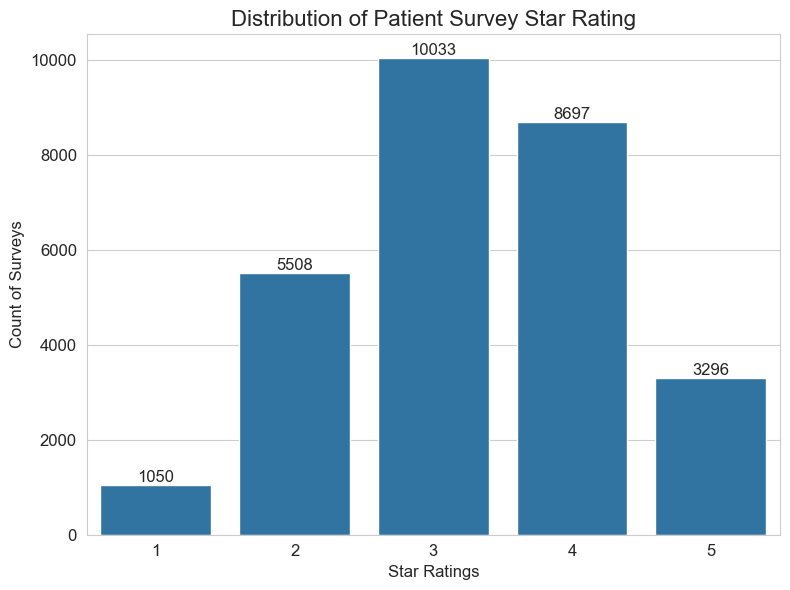

In [5]:
# Create bar chart for distribution of star ratings

# Set the theme for the grid lines for better readability
sns.set_style("whitegrid")

# Create a figure
plt.figure(figsize = (8, 6))

# Create axes
ax = sns.countplot(
    data = survey_clean, 
    x = 'Patient Survey Star Rating')

# Adding data labels
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 12)
    

# Create a title for the chart
plt.title('Distribution of Patient Survey Star Rating', fontsize = 16)
plt.xlabel('Star Ratings', fontsize = 12)
plt.ylabel('Count of Surveys', fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

# Formatting
plt.tight_layout()
plt.show()

Average Star Rating Across HCAHPS Questions:
HCAHPS Question
Recommend hospital               3.637280
Nurse communication              3.421914
Discharge information            3.366184
Cleanliness                      3.341625
Summary star rating              3.289673
Overall hospital rating          3.286209
Doctor communication             3.263854
Quietness                        3.151134
Communication about medicines    2.660579
Name: Patient Survey Star Rating, dtype: float64
------------------------------------------------------------


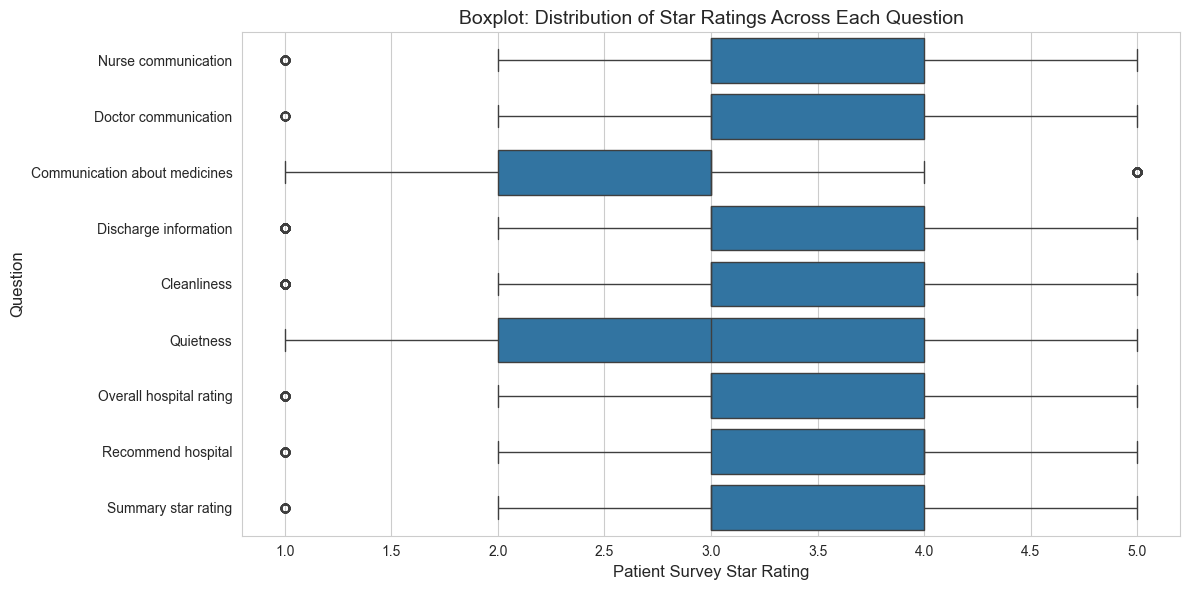

In [6]:
# Figure out if all measures are represented equally
survey_clean['HCAHPS Question'].value_counts()

# Find the average rating of each question
hcahps_avg_ratings = survey_clean.groupby('HCAHPS Question')['Patient Survey Star Rating'].mean().sort_values(ascending = False)
print("Average Star Rating Across HCAHPS Questions:")
print(hcahps_avg_ratings)
print("--" * 30)

# Plot the distribution of star ratings across each question

# Create a figure
plt.figure(figsize = (12, 6))

# Create the boxplot with seaborn
sns.boxplot(
    data = survey_clean,
    x = 'Patient Survey Star Rating',
    y = 'HCAHPS Question')

# Title the figure
plt.title('Boxplot: Distribution of Star Ratings Across Each Question', fontsize = 14)
plt.xlabel("Patient Survey Star Rating", fontsize = 12)
plt.ylabel("Question", fontsize = 12)

# Formatting
plt.tight_layout()
plt.show()

In [7]:
# Find out how many facilities are in the dataset
print("--" * 30)
print("Number of Facilities in Survey Dataset:")
print(survey_clean['Facility ID'].nunique(), " hospitals")
print("--" * 30)

print("Survey Columns:")
print(survey_clean.columns)
print("--" * 30)
# print(survey_clean.head(10))

# Assess the answer description
print("HCAHPS Question and Answer Description Value Counts:")
print(survey_clean[['HCAHPS Question', 'HCAHPS Answer Description']].value_counts())
print("--" * 30)

# Seems like the question and the answer description are the same
# Drop the 'Answer Description' column
survey_clean = survey_clean.drop(columns = ['HCAHPS Answer Description'])

# Double check the column was successfully dropped
print("Survey Columns (Answer Descriptions Dropped):")
print(survey_clean.columns)
print("--" * 30)

------------------------------------------------------------
Number of Facilities in Survey Dataset:
3176  hospitals
------------------------------------------------------------
Survey Columns:
Index(['Facility ID', 'Facility Name', 'HCAHPS Measure ID', 'HCAHPS Question',
       'HCAHPS Answer Description', 'Patient Survey Star Rating', 'Start Date',
       'End Date'],
      dtype='str')
------------------------------------------------------------
HCAHPS Question and Answer Description Value Counts:
HCAHPS Question                HCAHPS Answer Description                  
Nurse communication            Nurse communication - star rating              3176
Doctor communication           Doctor communication - star rating             3176
Communication about medicines  Communication about medicines - star rating    3176
Discharge information          Discharge information - star rating            3176
Cleanliness                    Cleanliness - star rating                      3176
Quie

In [8]:
# Assess the date distribution for the survey dataset
print(survey_clean['Start Date'].value_counts())
print(survey_clean['End Date'].value_counts())

Start Date
07/01/2024    28584
Name: count, dtype: int64
End Date
06/30/2025    28584
Name: count, dtype: int64


### Healthcare Acquired Infections

In [9]:
# Reminder on hai columns
print("Healthcare Acquired Infection Columns: ")
print(hai_clean.columns)
print("--"*30)

# Assess how and what measures there are
print("Number of HAI Measures: ", hai_clean['Measure ID'].nunique())
print("--"*30)
print("HAI Measure Names: ")
print(hai_clean['Measure Name'].value_counts())
print("--"*30)

# Defining line variable for easier formatting
line = "--" * 30

# Check for how many facilities are in this dataset
print("Number of Facilities: ")
print(hai_clean['Facility ID'].nunique())
print(line)

# Double check for null values
print("Number of Null Scores:")
print(hai_clean['Score'].isnull().sum())
print(line)

# Check to see what the scores look like
print(hai_clean['Score'].value_counts())
print(line)

# Check to see if there are any other 'Not Available' or 'Not Applicable' values
print("Checking for N/As:")

na_values = 0
na_columns = []

for column, row in hai_clean.items():
    for value in row:
        if str(value) in ['Not Applicable', 'Not Available']:
            na_values += 1
            if column not in na_columns:
                na_columns.append(column)
            else:
                continue
        else:
            continue

print("Columns: ", na_columns)
print("Number of Row Within Dataset Containing N/A values: ", na_values)
print(line)

# Remove the N/A values from the dataset
print("HAI Dataset Shape (Before Dropping N/A Values from 'Compared to National'):")
print(hai_clean.shape)
hai_clean = hai_clean[~hai_clean['Compared to National'].isin(['Not Applicable', 'Not Available'])]
print("HAI Dataset Shape (After Dropping N/A Values from 'Compared to National'):")
print(hai_clean.shape)
print(line)

# Check the data types for the hai_clean dataset
print("HAI Data Info: ")
print(hai_clean.info())


Healthcare Acquired Infection Columns: 
Index(['Facility ID', 'Facility Name', 'Measure ID', 'Measure Name',
       'Compared to National', 'Score', 'Start Date', 'End Date'],
      dtype='str')
------------------------------------------------------------
Number of HAI Measures:  18
------------------------------------------------------------
HAI Measure Names: 
Measure Name
Clostridium Difficile (C.Diff): Patient Days                                                          4075
Clostridium Difficile (C.Diff): Observed Cases                                                        4070
MRSA Bacteremia: Patient Days                                                                         4035
MRSA Bacteremia: Observed Cases                                                                       4035
Catheter Associated Urinary Tract Infections (ICU + select Wards): Number of Urinary Catheter Days    4001
Catheter Associated Urinary Tract Infections (ICU + select Wards): Observed Cases      

In [10]:
# Describe the score column
print("HAI Scores Described: ")
print(hai_clean['Score'].describe())
print(line)

# Seems like the range is vast therefore each measure must have different ranges
# print("HAI Score Described Grouped by Measure")
# print(hai_clean['Score'].groupby(hai_clean['Measure Name']).describe())
# print(line)

# Too messy -- take the mean, min, and max is sufficient
print("Aggregated Mean, Min, and Max for Various Measures:")

agg_hai_score = hai_clean.groupby('Measure Name')['Score'].agg(
    Mean = 'mean',
    Min = 'min',
    Max = 'max').sort_values('Mean', ascending = False)

print(agg_hai_score)
print(line)


HAI Scores Described: 
count     33852.000000
mean      10043.201031
std       34983.036842
min           0.000000
25%           0.522000
50%           3.000000
75%        1825.000000
max      910011.000000
Name: Score, dtype: float64
------------------------------------------------------------
Aggregated Mean, Min, and Max for Various Measures:
                                                            Mean      Min  \
Measure Name                                                                
MRSA Bacteremia: Patient Days                       88257.725116  13445.0   
Clostridium Difficile (C.Diff): Patient Days        51586.366499   1740.0   
Central Line Associated Bloodstream Infection: ...   8619.619097    982.0   
Catheter Associated Urinary Tract Infections (I...   7206.755804    411.0   
SSI - Abdominal Hysterectomy: Number of Procedures    264.956954     69.0   
SSI - Colon Surgery: Number of Procedures             181.329961     28.0   
Clostridium Difficile (C.Diff): Obse

# of HAI Measures:  18
['Central Line Associated Bloodstream Infection: Number of Device Days', 'Central Line Associated Bloodstream Infection (ICU + select Wards): Observed Cases', 'Central Line Associated Bloodstream Infection (ICU + select Wards)', 'Catheter Associated Urinary Tract Infections (ICU + select Wards): Number of Urinary Catheter Days', 'Catheter Associated Urinary Tract Infections (ICU + select Wards): Observed Cases', 'Catheter Associated Urinary Tract Infections (ICU + select Wards)', 'SSI - Colon Surgery: Number of Procedures', 'SSI - Colon Surgery: Observed Cases', 'SSI - Colon Surgery', 'MRSA Bacteremia: Patient Days', 'MRSA Bacteremia: Observed Cases', 'MRSA Bacteremia', 'Clostridium Difficile (C.Diff): Patient Days', 'Clostridium Difficile (C.Diff): Observed Cases', 'Clostridium Difficile (C.Diff)', 'SSI - Abdominal Hysterectomy: Number of Procedures', 'SSI - Abdominal Hysterectomy: Observed Cases', 'SSI - Abdominal Hysterectomy']
--------------------------------

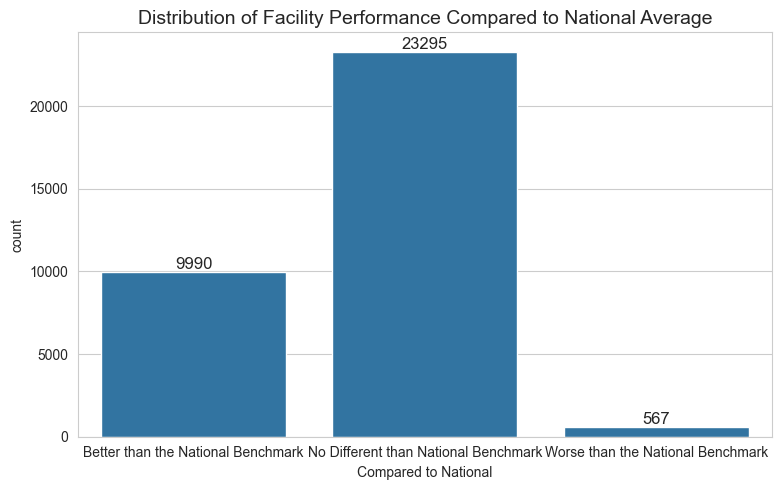

In [11]:
# Dig deeper into the measures, scores, and compared to national average

# Place all the unique measure names in a list
hai_measures = []

# Create for loop
for measure in hai_clean['Measure Name'].unique():
    hai_measures.append(measure)

# Print for successful append
print("# of HAI Measures: ", len(hai_measures))
print(hai_measures)
print(line)

# Assess the values for the compared to national
print("Value Counts for 'Compared to National':")
print(hai_clean['Compared to National'].value_counts())
print(line)

# Create a figure to see how facilities stack against the national average
plt.figure(figsize = (8, 5))

# Use seaborn for histogram
ax = sns.countplot(data = hai_clean,
                   x = 'Compared to National')

for container in ax.containers:
    ax.bar_label(container, fontsize = 12)

plt.title('Distribution of Facility Performance Compared to National Average', fontsize = 14)
plt.tight_layout()
plt.show()

In [12]:
# Assess the date distribution for the hai dataset
print(hai_clean['Start Date'].value_counts())
print(hai_clean['End Date'].value_counts())

Start Date
07/01/2024    33852
Name: count, dtype: int64
End Date
06/30/2025    33852
Name: count, dtype: int64


### Timeliness and Cleanliness

In [13]:
# Pull the dataset columns
print(line)
print("Timeliness and Cleanliness Dataset Columns: ", timely_clean.columns.tolist())
print(line)

# Print the dataset
print("Distinct Date Durations:")
print(timely_clean[['Start Date', 'End Date']].value_counts())
print(line)

# See if there are any null values
# print(len(timely_clean['Score']))
print("Count of Numerical Score Values: ")
print((pd.to_numeric(timely_clean['Score'], errors = 'coerce')).isna().sum())



------------------------------------------------------------
Timeliness and Cleanliness Dataset Columns:  ['Facility ID', 'Facility Name', 'State', 'Condition', 'Measure ID', 'Measure Name', 'Score', 'Start Date', 'End Date']
------------------------------------------------------------
Distinct Date Durations:
Start Date  End Date  
07/01/2024  06/30/2025    28952
01/01/2024  12/31/2024    24485
10/01/2024  03/31/2025     4267
Name: count, dtype: int64
------------------------------------------------------------
Count of Numerical Score Values: 
3837


In [14]:
print("Patient Survey: " , survey_clean.shape)

print("HAI: ", hai_clean.shape)

print("Timely: ", timely_clean.shape)

Patient Survey:  (28584, 7)
HAI:  (33852, 8)
Timely:  (57704, 9)
